In [1]:
from backtesting import PortfolioBacktester
from utils import compute_log_returns, plot_pearson_heatmap


In [4]:

bt = PortfolioBacktester(
        portfolio_path="portfolio.json",
        start_date="2023-01-03",
    )
pv = bt.run()


Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 807 records


In [5]:
print(pv.head())
print(f"\nValor final del portafolio: ${pv['portfolio_value'].iloc[-1]:,.2f}")


            portfolio_value
Date                       
2023-01-03       108069.675
2023-01-04       103757.571
2023-01-05       100897.165
2023-01-06       102153.881
2023-01-09       103129.002

Valor final del portafolio: $186,028.98


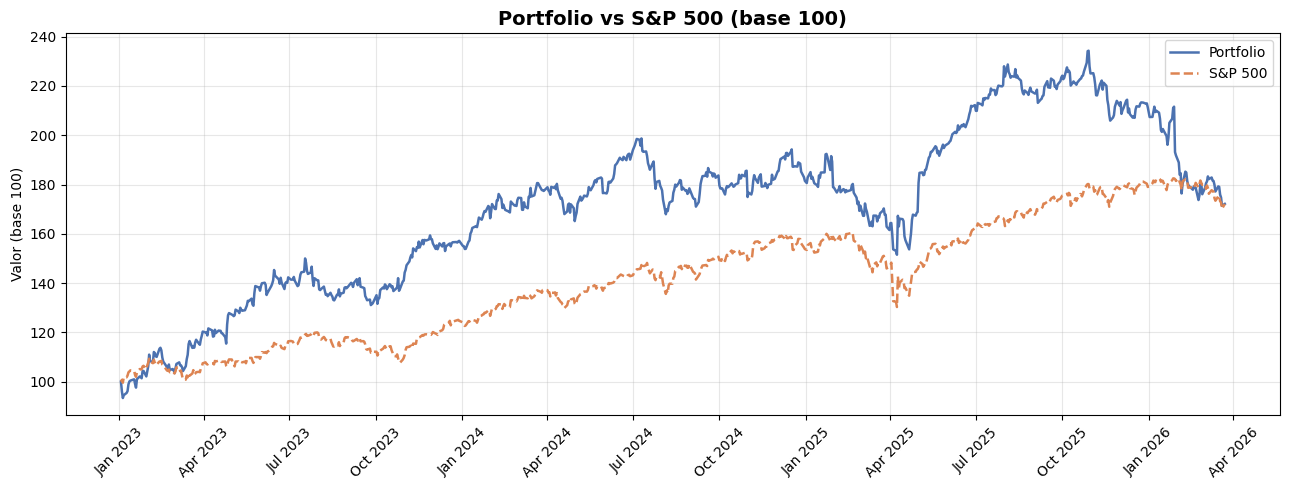

In [6]:
bt.plot()

In [7]:
df = bt.get_full_dataframe()
df

,AAPL.O,AMZN.O,NVDA.O,MSFT.O,GOOGL.O,KO,NOC.N,PBR.N,C,BIMBOA.MX,portfolio_value,SP500
Date,,,,,,,,,,,,
2023-01-03,125.07,85.82,14.315,239.58,89.12,62.95,540.33,9.5,45.78,84.89,108069.675,3824.139893
2023-01-04,126.36,85.14,14.749,229.1,88.08,62.92,526.45,9.71,46.96,85.39,103757.571,3852.969971
2023-01-05,125.02,83.12,14.265,222.31,86.2,62.2,528.52,10.13,46.75,87.73,100897.165,3808.100098
2023-01-06,129.62,86.08,14.859,224.93,87.34,63.4,521.42,10.28,47.31,88.41,102153.881,3895.080078
2023-01-09,130.15,87.36,15.628,227.12,88.02,62.61,495.41,10.24,47.54,90.3,103129.002,3892.090088
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-17,254.23,215.2,181.93,399.41,310.92,77.58,724.03,19.51,107.71,59.13,193522.69,6716.089844
2026-03-18,249.94,209.87,180.4,391.79,307.69,75.97,724.84,19.77,108.67,58.03,190127.41,6624.700195
2026-03-19,248.96,208.76,178.56,389.02,307.13,75.55,714.15,19.78,109.85,58.64,188835.68,6606.490234


In [8]:
from utils import compute_log_returns
# All numeric columns (stocks + portfolio_value + SP500)
log_ret = compute_log_returns(df)
log_ret.head()

,AAPL.O,AMZN.O,NVDA.O,MSFT.O,GOOGL.O,KO,NOC.N,PBR.N,C,BIMBOA.MX,portfolio_value,SP500
Date,,,,,,,,,,,,
2023-01-04,0.010261,-0.007955,0.029867,-0.044729,-0.011738,-0.000477,-0.026024,0.021864,0.025449,0.005873,-0.040719,0.007511
2023-01-05,-0.010661,-0.024012,-0.033366,-0.030086,-0.021575,-0.011509,0.003924,0.042345,-0.004482,0.027035,-0.027955,-0.011714
2023-01-06,0.036133,0.034992,0.040797,0.011716,0.013138,0.019109,-0.013525,0.014699,0.011907,0.007721,0.012378,0.022584
2023-01-09,0.004081,0.01476,0.050458,0.009689,0.007756,-0.012539,-0.05117,-0.003899,0.00485,0.021152,0.0095,-0.000768
2023-01-10,0.004446,0.028327,0.017821,0.007588,0.004534,-0.007696,0.000767,0.0203,0.01358,0.000886,0.007791,0.006954


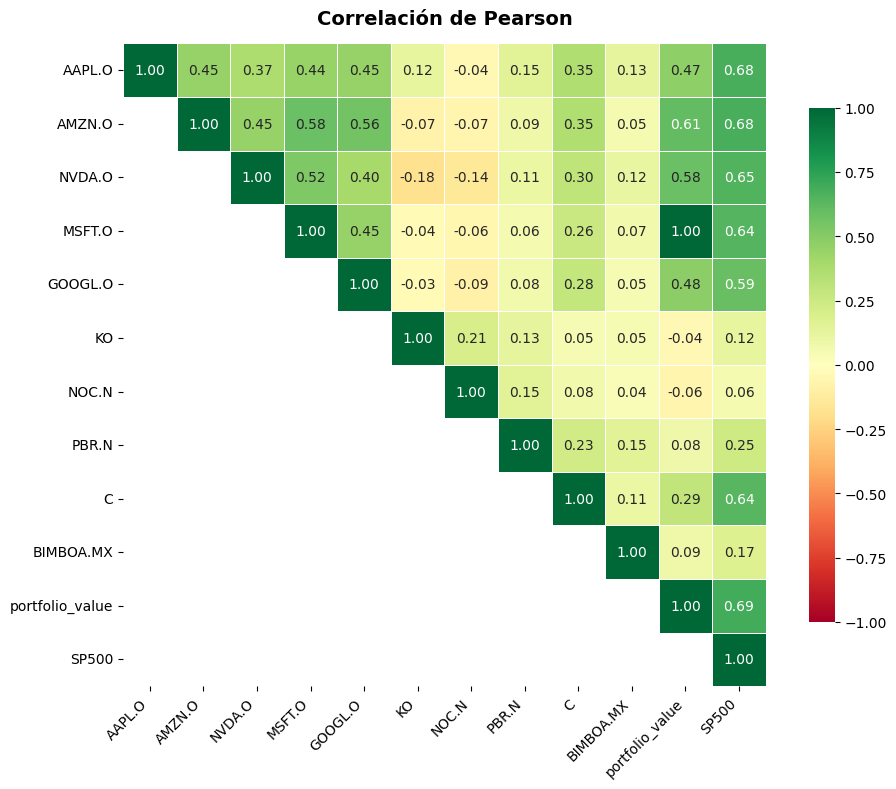

NOC.N              0.057486
KO                 0.117516
BIMBOA.MX          0.174727
PBR.N              0.248571
GOOGL.O            0.586943
C                  0.640540
MSFT.O             0.642770
NVDA.O             0.648513
AAPL.O             0.677273
AMZN.O             0.679154
portfolio_value    0.688634
SP500              1.000000
Name: SP500, dtype: float64


In [10]:

# 3a. Heatmap de TODOS los activos + portafolio + SP500
corr = plot_pearson_heatmap(log_ret)

# La función también devuelve la matriz numérica
print(corr["SP500"].sort_values())  # ranking: más negativo = más contracíclico